# Cold Diffusion: CIFAR-10 Re-implementation

Re-implementation of *Cold Diffusion: Inverting Arbitrary Image Transforms Without Noise* (Bansal et al., 2022) on CIFAR-10. Walks through the three core experiments:

1. **Forward degradations** — visualizing inpainting, blur, and super-resolution as `D(x_0, t)` over `t = 0..T`.
2. **Reconstruction** — direct one-shot prediction vs. Algorithm 2 iterative sampling.
3. **Sampler comparison** — Algorithm 1 (naive) vs Algorithm 2 (paper §3.3), the headline empirical result.
4. **Metrics** — FID / SSIM / RMSE over the test set, mirroring Tables 1–3.
5. **Cold generation** — unconditional samples via the §5.3 random-color-fill trick.

Run order: top to bottom. Cells that train assume a CUDA GPU; if you only have CPU, set `TOTAL_STEPS` to something tiny just to verify the pipeline runs.

In [1]:
import sys, os, pathlib, subprocess

REPO_URL  = 'https://github.com/J0hns0n-Wang/CS4782_Final_Project.git'
REPO_NAME = 'CS4782_Final_Project'

def _find_root():
    here = pathlib.Path('.').resolve()
    for d in [here, *here.parents]:
        if (d / 'src' / '__init__.py').exists():
            return d
    for child in here.iterdir():
        if child.is_dir() and (child / 'src' / '__init__.py').exists():
            return child.resolve()
    return None

ROOT = _find_root()

# On Colab (incl. the VSCode Colab extension) the kernel runs on a fresh
# remote VM with no project files. Clone from GitHub if we can't find src/.
if ROOT is None:
    on_colab = 'google.colab' in sys.modules or os.path.exists('/content')
    if on_colab:
        target = pathlib.Path('/content') / REPO_NAME
        if not target.exists():
            subprocess.check_call(['git', 'clone', '--depth', '1', REPO_URL, str(target)])
        ROOT = target
    else:
        raise RuntimeError(
            "Could not find src/__init__.py walking up from "
            f"{pathlib.Path('.').resolve()}. Run this notebook from inside "
            "the CS4782_Final_Project folder, or set ROOT manually."
        )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

try:
    import torchmetrics  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics'])

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
torch.manual_seed(0)

project root: /content/CS4782_Final_Project
device: cpu


In [2]:
from src.training.dataset import cifar10_loaders
from src.degradations import GaussianMaskInpainting, GaussianBlur, SuperResolution
from src.diffusion.cold import ColdDiffusion
from src.models.unet import UNet
from src.models.ema import EMA
from src.training.train import train

train_loader, test_loader = cifar10_loaders(batch_size=64, num_workers=0)
x0_demo, _ = next(iter(test_loader))
x0_demo = x0_demo[:8].to(DEVICE)
print('demo batch:', x0_demo.shape, x0_demo.min().item(), x0_demo.max().item())

demo batch: torch.Size([8, 3, 32, 32]) 0.0 1.0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 1. Forward degradations

Visualize `D(x_0, t)` for `t = 0, T/4, T/2, 3T/4, T` for each operator. This is the paper's Figure 1, top three rows.

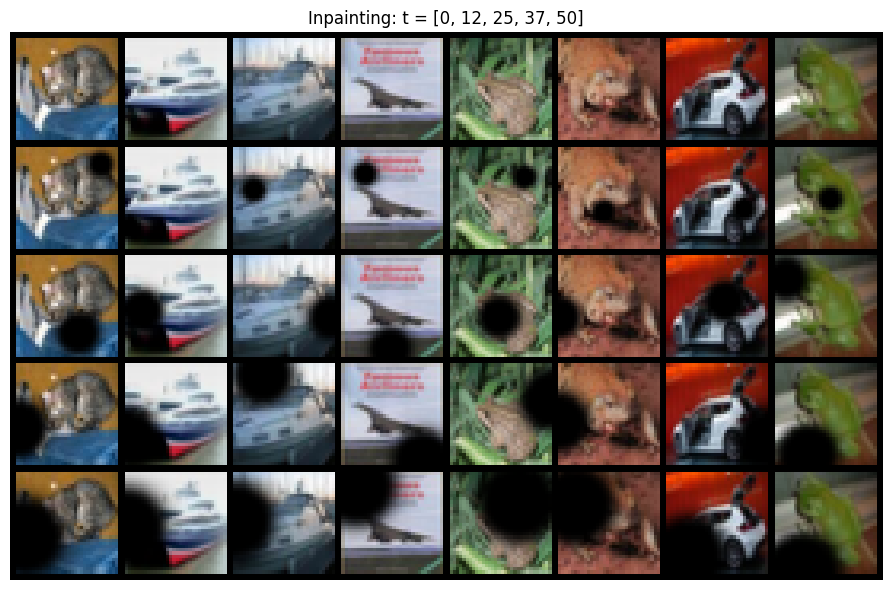

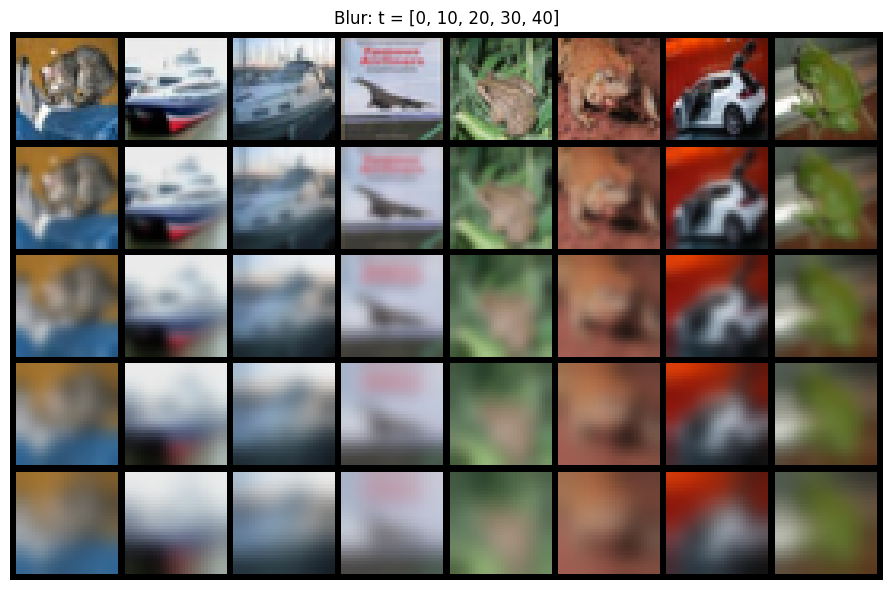

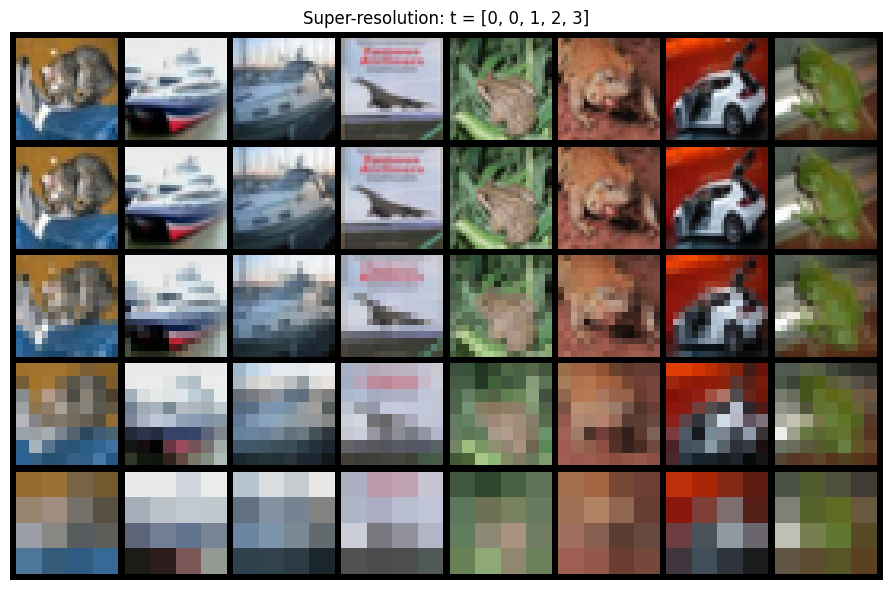

In [3]:
def show_degradation_progression(deg, T, x0, device, title=''):
    timesteps = [0, T // 4, T // 2, 3 * T // 4, T]
    rows = []
    deg = deg.to(device)
    for t_val in timesteps:
        t = torch.full((x0.shape[0],), t_val, device=device, dtype=torch.long)
        rows.append(deg(x0, t).clamp(0, 1).cpu())
    grid = make_grid(torch.cat(rows), nrow=x0.shape[0])
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(grid.permute(1, 2, 0))
    ax.set_title(f'{title}: t = {timesteps}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_degradation_progression(GaussianMaskInpainting(image_size=32, T=50), 50, x0_demo, DEVICE, 'Inpainting')
show_degradation_progression(GaussianBlur(kernel_size=11, T=40), 40, x0_demo, DEVICE, 'Blur')
show_degradation_progression(SuperResolution(image_size=32, T=3), 3, x0_demo, DEVICE, 'Super-resolution')

## 2. Train a Cold Diffusion model on the inpainting task

Per the paper this is the cheapest of the four tasks (60k gradient steps with batch 64). We expose a small `TOTAL_STEPS` so this notebook is runnable end-to-end on a free Colab GPU; bump it up for paper-quality results.

Skip this cell if you've already saved a checkpoint you want to load.

In [ ]:
TOTAL_STEPS = 5000   # full paper recipe: 60_000
RUN_DIR = 'results/checkpoints/inpainting_demo'

deg = GaussianMaskInpainting(image_size=32, T=50)
unet = UNet(image_size=32)
diffusion = ColdDiffusion(unet, deg, T=50)

ema = train(diffusion, train_loader, total_steps=TOTAL_STEPS, run_dir=RUN_DIR, device=DEVICE)

## 3. Reconstruction: direct vs Algorithm 2

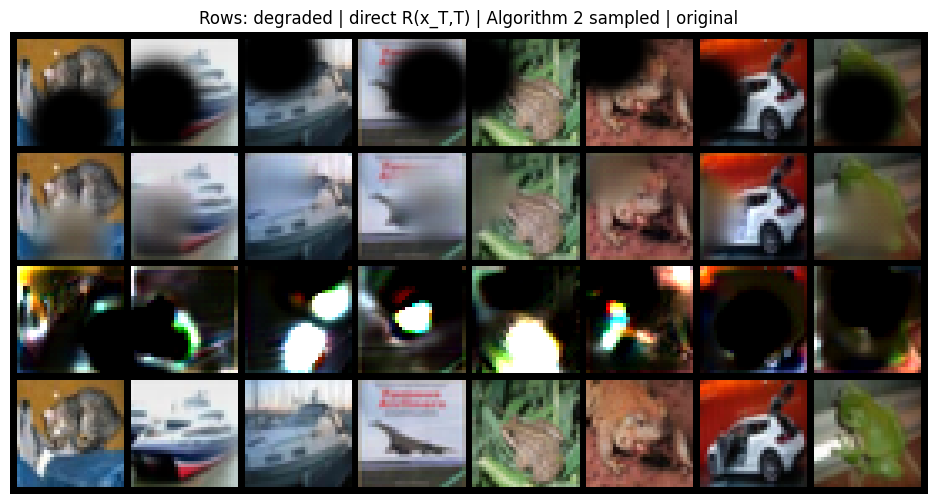

In [23]:
diff_eval = ColdDiffusion(ema.ema_model.to(DEVICE), deg.to(DEVICE), T=50).eval()
T = 50

with torch.no_grad():
    t_full = torch.full((x0_demo.shape[0],), T, device=DEVICE, dtype=torch.long)
    xT = diff_eval.q_sample(x0_demo, t_full)
    direct = diff_eval.predict_x0(xT, t_full).clamp(0, 1)
    sampled = diff_eval.sample_improved(xT).clamp(0, 1)

row_grid = torch.cat([xT.clamp(0,1).cpu(), direct.cpu(), sampled.cpu(), x0_demo.cpu()])
grid = make_grid(row_grid, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | direct R(x_T,T) | Algorithm 2 sampled | original')
ax.axis('off')
plt.show()

## 4. Sampler comparison: Algorithm 1 vs Algorithm 2

The paper's central empirical claim (§3.3, Fig. 2): for smooth deterministic degradations, the naive sampler accumulates errors. Algorithm 2 is constructed so that for linear `D` the iteration is exact regardless of `R`. Same trained model, just different reverse rule.

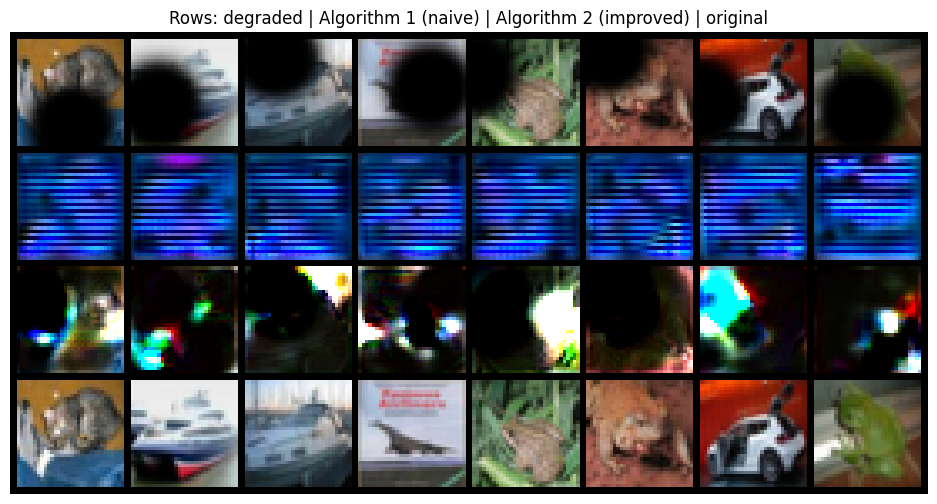

In [24]:
with torch.no_grad():
    naive = diff_eval.sample_naive(xT).clamp(0, 1)
    improved = diff_eval.sample_improved(xT).clamp(0, 1)

comp = torch.cat([xT.clamp(0,1).cpu(), naive.cpu(), improved.cpu(), x0_demo.cpu()])
grid = make_grid(comp, nrow=x0_demo.shape[0])
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Rows: degraded | Algorithm 1 (naive) | Algorithm 2 (improved) | original')
ax.axis('off')
plt.show()

## 5. Quantitative metrics (Tables 1–3 style)

Compute FID / SSIM / RMSE on the test set comparing degraded, direct, and sampled reconstructions to the originals.

In [25]:
from src.evaluation.metrics import evaluate_diffusion

results = evaluate_diffusion(diff_eval, test_loader, device=DEVICE, max_batches=8)
for name, m in results.items():
    print(f'{name:>9s}  FID={m.fid:7.2f}  SSIM={m.ssim:.3f}  RMSE={m.rmse:.3f}')

ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.

## 6. Cold generation (random-color seeds, §5.3)

Requires a model trained with `GenerativeInpainting` (the random-color-fill variant). The cell below does a small training run on that variant and then generates.

In [26]:
from src.generation.cold_gen import GenerativeInpainting, sample_generative

gen_deg = GenerativeInpainting(image_size=32, T=50)
gen_unet = UNet(image_size=32)
gen_diff = ColdDiffusion(gen_unet, gen_deg, T=50)

ema_gen = train(gen_diff, train_loader, total_steps=TOTAL_STEPS,
                run_dir='results/checkpoints/generative_inpainting_demo', device=DEVICE)

step    100/5000  loss 0.1586  (2.9 it/s)
step    200/5000  loss 0.0900  (2.9 it/s)
step    300/5000  loss 0.0756  (2.9 it/s)
step    400/5000  loss 0.0673  (2.9 it/s)
step    500/5000  loss 0.0613  (2.9 it/s)
step    600/5000  loss 0.0571  (2.9 it/s)
step    700/5000  loss 0.0542  (2.9 it/s)
step    800/5000  loss 0.0521  (2.9 it/s)
step    900/5000  loss 0.0500  (2.9 it/s)
step   1000/5000  loss 0.0484  (2.9 it/s)
step   1100/5000  loss 0.0470  (2.9 it/s)
step   1200/5000  loss 0.0451  (2.9 it/s)
step   1300/5000  loss 0.0444  (2.9 it/s)
step   1400/5000  loss 0.0433  (2.9 it/s)
step   1500/5000  loss 0.0426  (2.9 it/s)


: 

In [ ]:
gen_eval = ColdDiffusion(ema_gen.ema_model.to(DEVICE), gen_deg.to(DEVICE), T=50).eval()
samples = sample_generative(gen_eval, n=16, image_size=32, device=DEVICE)
grid = make_grid(samples.cpu(), nrow=8)
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(grid.permute(1, 2, 0))
ax.set_title('Cold generation samples: random color seeds → Algorithm 2')
ax.axis('off')
plt.show()